In [140]:
# ! pip install torch torchvision

In [141]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt
from statistics import mean

%matplotlib inline

In [142]:
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])

dataset = MNIST(root="./data", download=True, transform=transform)
testset = MNIST(root='./data', train=False, download=True, transform=transform)

In [143]:
image, label = dataset[0]
image.shape # the dims represent color channel, width and height

torch.Size([1, 28, 28])

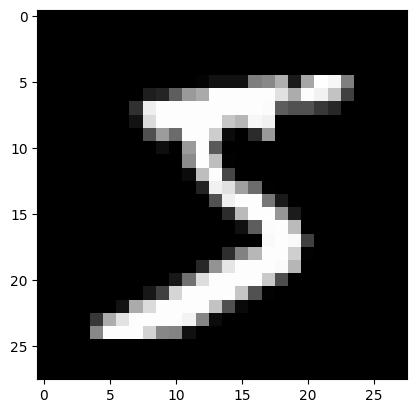

In [144]:
plt.imshow(image.permute(1, 2, 0), cmap='gray')

In [145]:
label

5

In [146]:
len(dataset), len(testset)

(60000, 10000)

In [147]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [148]:
val_data_size = 10000
train_data_size = len(dataset) - val_data_size

train_ds, val_ds = random_split(dataset, [train_data_size, val_data_size])
len(train_ds), len(val_ds)

(50000, 10000)

In [149]:
batch_size = 1584

In [150]:
train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count())
valid_dataloader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())
test_dataloader = DataLoader(testset, shuffle=False, num_workers=os.cpu_count())

In [151]:
os.cpu_count()

12

In [152]:
class MNISTModel(nn.Module):
    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        self.l1 = nn.Linear(in_size, hidden_size)
        self.l2 = nn.Linear(hidden_size, out_size)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.l1(x)
        out = F.relu(out)
        out = self.l2(out)
        return out


In [153]:
def checkpoint(model, filename):
    torch.save(model.state_dict(), filename)
    
def resume(model, filename):
    model.load_state_dict(torch.load(filename))

In [154]:
input_size = 784
hidden_size = 32
num_classes = 10

In [155]:
model = MNISTModel(in_size=input_size, hidden_size=hidden_size, out_size=num_classes)

In [156]:
loss_fn = nn.CrossEntropyLoss()
# https://paperswithcode.com/method/sgd-with-momentum
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

In [157]:
def train(dataloader, model, loss_fn, optimizer, epoch):
    
    # Total size of dataset for reference
    size = 0
    
    # places your model into training mode
    model.train()
    
    # loss batch
    batch_loss = {}
    batch_accuracy = {}
    
    correct = 0
    _correct = 0
    
    # Gives X , y for each batch
    for batch, (X, y) in enumerate(dataloader):
        
        # Converting device to cuda
        X, y = X.to(device), y.to(device)
        model.to(device)
        
        # Compute prediction error / loss
        # 1. Compute y_pred 
        # 2. Compute loss between y and y_pred using selectd loss function
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backpropagation on optimizing for loss
        # 1. Sets gradients as 0 
        # 2. Compute the gradients using back_prop
        # 3. update the parameters using the gradients from step 2
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        _correct = (y_pred.argmax(dim=1) == y).type(torch.float).sum().item()
        _batch_size = len(X)
        
        correct += _correct
        
        # Updating loss_batch and batch_accuracy
        batch_loss[batch] = loss.item()
        batch_accuracy[batch] = _correct/_batch_size
        
        size += _batch_size
        
        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}]")
    
    correct/=size
    print(f"Train Accuracy: {(100*correct)}%")
    checkpoint(model, f"epoch-{epoch}.pth")
    
    return batch_loss , batch_accuracy

In [158]:
def validation(dataloader, model, loss_fn):
    
    # Total size of dataset for reference
    size = 0
    num_batches = len(dataloader)
    
    # Setting the model under evaluation mode.
    model.eval()

    test_loss, correct = 0, 0
    
    _correct = 0
    _batch_size = 0
    
    batch_loss = {}
    batch_accuracy = {}
    
    with torch.no_grad():
        
        # Gives X , y for each batch
        for batch , (X, y) in enumerate(dataloader):
            
            X, y = X.to(device), y.to(device)
            model.to(device)
            pred = model(X)
            
            batch_loss[batch] = loss_fn(pred, y).item()
            test_loss += batch_loss[batch]
            _batch_size = len(X)
            
            
            _correct = (pred.argmax(dim=1) == y).type(torch.float).sum().item()
            correct += _correct
            
            size+=_batch_size
            batch_accuracy[batch] = _correct/_batch_size
    
    ## Calculating loss based on loss function defined
    test_loss /= num_batches
    
    ## Calculating Accuracy based on how many y match with y_pred
    correct /= size
    
    print(f"Valid Error: \n Accuracy: {(100*correct)}%, Avg loss: {test_loss}% \n")
    
    return batch_loss , batch_accuracy

In [159]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0.02):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        print(f"min valid_loss: {self.min_validation_loss}")
        print(f"valid_loss: {validation_loss}")
        print(f"delta: {validation_loss-self.min_validation_loss}")

        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [160]:
stop_here = EarlyStopper()

In [ ]:
train_batch_loss = []
train_batch_accuracy = []
valid_batch_accuracy = []
valid_batch_loss = []
train_epoch_no = []
valid_epoch_no = []

epochs = 1000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    _train_batch_loss , _train_batch_accuracy = train(train_dataloader, model, loss_fn, optimizer,t)
    _valid_batch_loss , _valid_batch_accuracy = validation(valid_dataloader, model, loss_fn)
    for i in range(len(_train_batch_loss)):
        train_batch_loss.append(_train_batch_loss[i])
        train_batch_accuracy.append(_train_batch_accuracy[i])
        train_epoch_no.append( t + float((i+1)/len(_train_batch_loss)))     
    for i in range(len(_valid_batch_loss)):
        valid_batch_loss.append(_valid_batch_loss[i])
        valid_batch_accuracy.append(_valid_batch_accuracy[i])
        valid_epoch_no.append( t + float((i+1)/len(_valid_batch_loss))) 
        
    check = stop_here.early_stop(mean(valid_batch_loss))
    if check== True:
        print(f'Early stopping criteria ia met on epoch {t}')
        break
    
print("Done!")

Epoch 1
-------------------------------
loss: 2.305794  [    0]
Train Accuracy: 20.756%
Valid Error: 
 Accuracy: 33.18%, Avg loss: 2.116417578288487% 

min valid_loss: inf
valid_loss: 2.116417578288487
delta: -inf
Epoch 2
-------------------------------
loss: 2.112517  [    0]
Train Accuracy: 44.29%
Valid Error: 
 Accuracy: 54.6%, Avg loss: 1.8805607557296753% 

min valid_loss: 2.116417578288487
valid_loss: 1.9984891670090812
delta: -0.1179284112794059
Epoch 3
-------------------------------
loss: 1.882120  [    0]
Train Accuracy: 60.23%
Valid Error: 
 Accuracy: 64.97%, Avg loss: 1.6440556389944894% 

min valid_loss: 1.9984891670090812
valid_loss: 1.880344657670884
delta: -0.1181445093381972
Epoch 4
-------------------------------
loss: 1.633422  [    0]
Train Accuracy: 67.464%
Valid Error: 
 Accuracy: 70.57%, Avg loss: 1.421935268810817% 

min valid_loss: 1.880344657670884
valid_loss: 1.7657423104558672
delta: -0.11460234721501683
Epoch 5
-------------------------------
loss: 1.421011

loss: 0.376576  [    0]
Train Accuracy: 89.206%
Valid Error: 
 Accuracy: 89.08%, Avg loss: 0.39669010043144226% 

min valid_loss: 0.7196171104391932
valid_loss: 0.7101192572036711
delta: -0.009497853235522102
Epoch 35
-------------------------------
loss: 0.401652  [    0]
Train Accuracy: 89.282%
Valid Error: 
 Accuracy: 89.11%, Avg loss: 0.3934097077165331% 

min valid_loss: 0.7101192572036711
valid_loss: 0.7010704129326101
delta: -0.009048844271061007
Epoch 36
-------------------------------
loss: 0.345269  [    0]
Train Accuracy: 89.324%
Valid Error: 
 Accuracy: 89.18%, Avg loss: 0.39071183119501385% 

min valid_loss: 0.7010704129326101
valid_loss: 0.6924493412176768
delta: -0.008621071714933315
Epoch 37
-------------------------------
loss: 0.399744  [    0]
Train Accuracy: 89.42999999999999%
Valid Error: 
 Accuracy: 89.3%, Avg loss: 0.3875846820218222% 

min valid_loss: 0.6924493412176768
valid_loss: 0.684209755834005
delta: -0.008239585383671755
Epoch 38
-------------------------

loss: 0.293491  [    0]
Train Accuracy: 90.666%
Valid Error: 
 Accuracy: 90.36%, Avg loss: 0.34145903161593844% 

min valid_loss: 0.5418033679842433
valid_loss: 0.538813154008597
delta: -0.002990213975646361
Epoch 68
-------------------------------
loss: 0.318282  [    0]
Train Accuracy: 90.684%
Valid Error: 
 Accuracy: 90.56%, Avg loss: 0.3400379419326782% 

min valid_loss: 0.538813154008597
valid_loss: 0.5358899891251275
delta: -0.0029231648834694424
Epoch 69
-------------------------------
loss: 0.325211  [    0]
Train Accuracy: 90.7%
Valid Error: 
 Accuracy: 90.42999999999999%, Avg loss: 0.33949315547943115% 

min valid_loss: 0.5358899891251275
valid_loss: 0.5330436582027261
delta: -0.0028463309224013855
Epoch 70
-------------------------------
loss: 0.338438  [    0]
Train Accuracy: 90.7%
Valid Error: 
 Accuracy: 90.55%, Avg loss: 0.3386214928967612% 

min valid_loss: 0.5330436582027261
valid_loss: 0.5302661986983552
delta: -0.002777459504370916
Epoch 71
--------------------------

loss: 0.308829  [    0]
Train Accuracy: 91.398%
Valid Error: 
 Accuracy: 90.99000000000001%, Avg loss: 0.3193687881742205% 

min valid_loss: 0.4710387137287107
valid_loss: 0.46952201447316577
delta: -0.0015166992555449288
Epoch 101
-------------------------------
loss: 0.278953  [    0]
Train Accuracy: 91.396%
Valid Error: 
 Accuracy: 91.02%, Avg loss: 0.3188396223953792% 

min valid_loss: 0.46952201447316577
valid_loss: 0.46803010960110847
delta: -0.0014919048720573036
Epoch 102
-------------------------------
loss: 0.306061  [    0]
Train Accuracy: 91.432%
Valid Error: 
 Accuracy: 91.02%, Avg loss: 0.31810697061674936% 

min valid_loss: 0.46803010960110847
valid_loss: 0.4665602749051834
delta: -0.001469834695925043
Epoch 103
-------------------------------
loss: 0.343085  [    0]
Train Accuracy: 91.458%
Valid Error: 
 Accuracy: 91.03%, Avg loss: 0.31776068466050283% 

min valid_loss: 0.4665602749051834
valid_loss: 0.46511561868921564
delta: -0.0014446562159677878
Epoch 104
----------

Train Accuracy: 91.918%
Valid Error: 
 Accuracy: 91.46%, Avg loss: 0.3045698404312134% 

min valid_loss: 0.4321627617857318
valid_loss: 0.4311961487451673
delta: -0.0009666130405645013
Epoch 133
-------------------------------
loss: 0.277839  [    0]
Train Accuracy: 91.95400000000001%
Valid Error: 
 Accuracy: 91.45%, Avg loss: 0.30394107954842703% 

min valid_loss: 0.4311961487451673
valid_loss: 0.4302393437136129
delta: -0.0009568050315544308
Epoch 134
-------------------------------
loss: 0.282788  [    0]
Train Accuracy: 91.92%
Valid Error: 
 Accuracy: 91.47%, Avg loss: 0.3039488324097225% 

min valid_loss: 0.4302393437136129
valid_loss: 0.429296877211345
delta: -0.0009424665022678691
Epoch 135
-------------------------------
loss: 0.270047  [    0]
Train Accuracy: 91.97800000000001%
Valid Error: 
 Accuracy: 91.47999999999999%, Avg loss: 0.30378234812191557% 

min valid_loss: 0.429296877211345
valid_loss: 0.42836713995883074
delta: -0.0009297372525142733
Epoch 136
------------------

In [ ]:

plt.plot(train_epoch_no , train_batch_accuracy)
plt.title("Train Batch Accuracy")
plt.xlabel("Epochs") 
plt.ylabel("Train Accuracy") 

plt.show()


In [ ]:
torch.get_num_threads()

In [ ]:
plt.plot(train_epoch_no , train_batch_loss)
plt.title("Train Batch Loss")
plt.xlabel("Epochs") 
plt.ylabel("Train Loss") 

plt.show()

In [ ]:
plt.plot(valid_epoch_no , valid_batch_accuracy)
plt.title("Valid Batch Accuracy")
plt.xlabel("Epochs") 
plt.ylabel("Valid Accuracy") 
plt.show()



In [ ]:
plt.plot(valid_epoch_no , valid_batch_loss)
plt.title("Valid Batch Loss")
plt.xlabel("Epochs") 
plt.ylabel("Valid Loss")
plt.show()

In [ ]:
test_loss , test_accuracy = validation(test_dataloader, model, loss_fn)